#Test 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

path = '/content/drive/MyDrive/MLB_Park_Factors_MultiYear.csv'
df = pd.read_csv(path)

df.head()


,Rk.,Team,Venue,Year,Park Factor,wOBACon,xwOBACon,BACON,xBACON,HardHit,R,OBP,H,1B,2B,3B,HR,BB,SO,PA
0,1,Rockies,Coors Field,1999,122,122,NaN,117,NaN,NaN,149,116,124,118,115,165,164,102,80,18674
1,2,Guardians,Progressive Field,1999,105,108,NaN,106,NaN,NaN,110,104,104,103,101,96,115,110,109,18768
2,3,Cubs,Wrigley Field,1999,105,107,NaN,105,NaN,NaN,110,102,106,104,102,111,126,93,99,17904
3,4,Rangers,Globe Life Park in Arlington,1999,103,103,NaN,103,NaN,NaN,106,102,107,108,101,139,106,94,92,18216
4,5,Brewers,Milwaukee County Stadium,1999,102,99,NaN,100,NaN,NaN,104,103,104,109,91,79,103,101,85,17976


In [ ]:
df = df[df["Year"] > 2014]
df["Differential"] = df["wOBACon"] - df["xwOBACon"]
df.head()

,Rk.,Team,Venue,Year,Park Factor,wOBACon,xwOBACon,BACON,xBACON,HardHit,...,OBP,H,1B,2B,3B,HR,BB,SO,PA,Differential
480,1,Rockies,Coors Field,2015,117,116,102.0,115,103.0,108.0,...,115,122,119,125,192,122,99,84,17574,14.0
481,2,Rangers,Globe Life Park in Arlington,2015,107,104,104.0,104,103.0,104.0,...,108,106,107,108,104,99,111,88,18401,0.0
482,3,Red Sox,Fenway Park,2015,107,107,99.0,108,100.0,100.0,...,107,110,110,122,109,95,94,93,17675,8.0
483,4,D-backs,Chase Field,2015,105,106,105.0,106,103.0,107.0,...,104,106,101,121,166,94,101,98,17644,1.0
484,5,Orioles,Oriole Park at Camden Yards,2015,104,106,102.0,103,101.0,100.0,...,101,104,103,97,63,133,91,100,16819,4.0


In [ ]:
df["Differential"].mean()

np.float64(-0.015151515151515152)

<Axes: title={'center': 'Distribution of Park Factor Values, 2015-2025'}, ylabel='Frequency'>

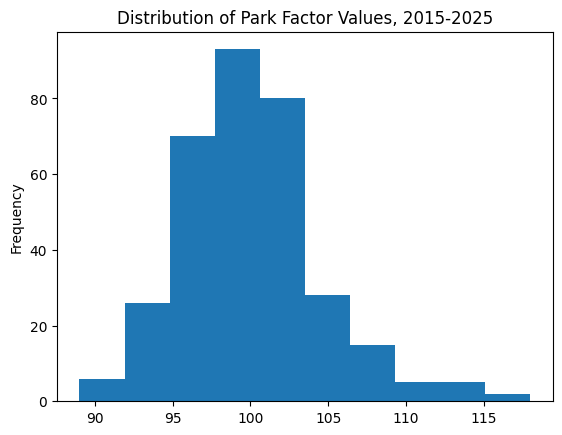

In [ ]:
df["Park Factor"].plot.hist(title="Distribution of Park Factor Values, 2015-2025")

<Axes: title={'center': 'Distribution of wOBACon - xwOBACon, 2015-2025'}, ylabel='Frequency'>

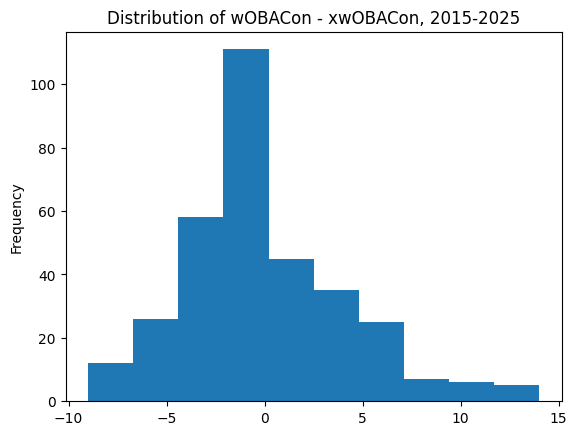

In [ ]:
df["Differential"].plot.hist(title="Distribution of wOBACon - xwOBACon, 2015-2025")

<Axes: xlabel='Park Factor', ylabel='Differential'>

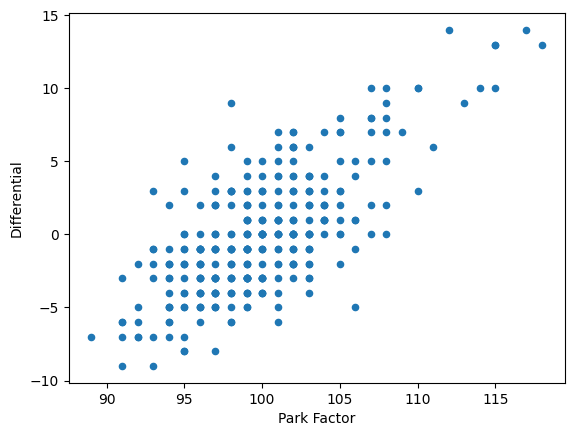

In [ ]:
df.plot.scatter(x="Park Factor", y="Differential", title="")

<Axes: title={'center': 'Park Factor vs Differential Between wOBACon and xwOBACon, By Team'}, xlabel='Park Factor', ylabel='Differential'>

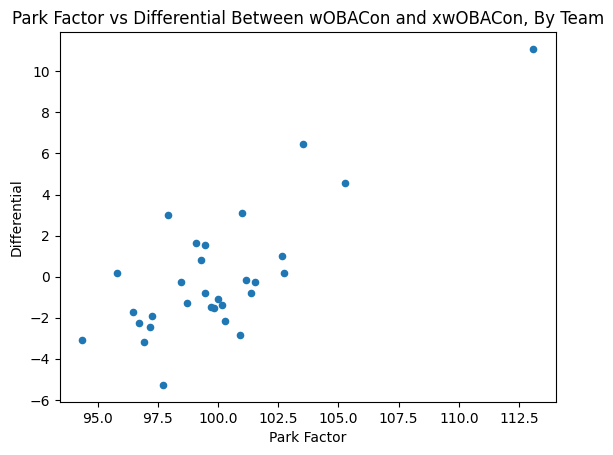

In [ ]:
df.groupby("Team")[["Park Factor", "Differential"]].mean().plot.scatter(x="Park Factor", y="Differential", title="Park Factor vs Differential Between wOBACon and xwOBACon, By Team")

<Axes: title={'center': 'Park Factor vs wOBACon, By Team (2015-2025)'}, xlabel='Park Factor', ylabel='wOBACon'>

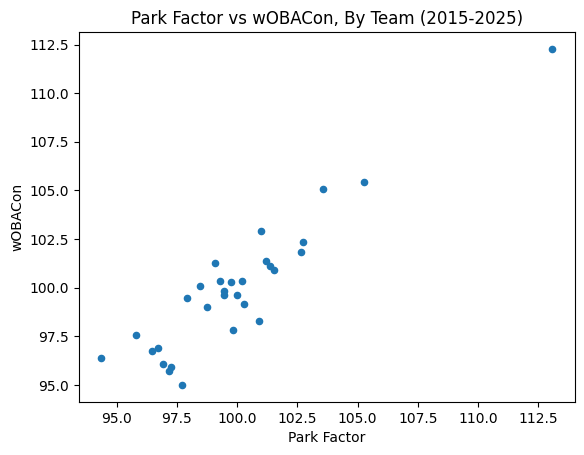

In [ ]:
df.groupby("Team")[["Park Factor", "wOBACon"]].mean().plot.scatter(x="Park Factor", y="wOBACon", title="Park Factor vs wOBACon, By Team (2015-2025)")

In [ ]:
df[["xwOBACon", "Park Factor"]].corr()

,xwOBACon,Park Factor
xwOBACon,1.000000,0.517917
Park Factor,0.517917,1.000000


In [ ]:
df_2025 = df[df["Year"] == 2025]
df_2025[["Differential", "Park Factor"]].corr()

,Differential,Park Factor
Differential,1.000000,0.851808
Park Factor,0.851808,1.000000


In [ ]:
corr_by_year = (
    df[df["Year"].between(2015, 2025)]
    .groupby("Year")
    .apply(lambda x: x["Differential"].corr(x["Park Factor"]))
)
corr_by_year.rename("Correlation By Season")

/tmp/ipython-input-4234368726.py:4: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,Correlation By Season
Year,
2015,0.721770
2016,0.710628
2017,0.572541
2018,0.671064
2019,0.770434
2020,0.586283
2021,0.786545
2022,0.770093
2023,0.692960


<Axes: title={'center': 'Correlation Between Differential and Park Factor Over Time'}, xlabel='Season', ylabel='Correlation'>

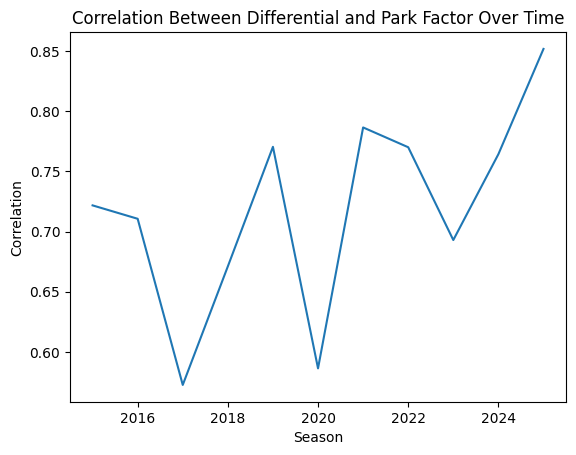

In [ ]:
corr_by_year.plot.line(xlabel = "Season", ylabel="Correlation", title="Correlation Between Differential and Park Factor Over Time")

In [ ]:
import plotly.express as px

px.line(corr_by_year)

In [ ]:
df.columns

Index(['Rk.', 'Team', 'Venue', 'Year', 'Park Factor', 'wOBACon', 'xwOBACon',
       'BACON', 'xBACON', 'HardHit', 'R', 'OBP', 'H', '1B', '2B', '3B', 'HR',
       'BB', 'SO', 'PA', 'Differential'],
      dtype='object')

<Axes: title={'center': 'R^2 For Each Statistic With Park Factor'}>

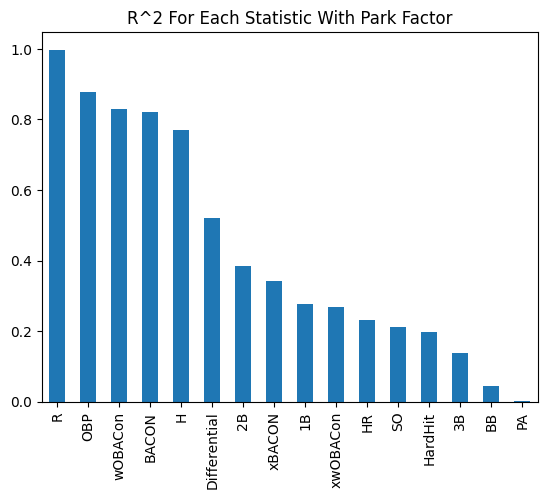

In [ ]:
cols_after = df.columns[df.columns.get_loc('Park Factor') + 1:]

r_2 = df[cols_after].corrwith(df['Park Factor']) ** 2

r_2 = r_2.sort_values(ascending=False).rename("Correlation")

r_2.plot.bar(title="R^2 For Each Statistic With Park Factor")

In [ ]:
import statsmodels.api as sm

X = sm.add_constant(df['wOBACon'])
y = df['Park Factor']

model = sm.OLS(y, X).fit()
df['residuals'] = model.resid

model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            Park Factor   R-squared:                       0.829
Model:                            OLS   Adj. R-squared:                  0.829
Method:                 Least Squares   F-statistic:                     1594.
Date:                Tue, 10 Feb 2026   Prob (F-statistic):          5.42e-128
Time:                        04:49:07   Log-Likelihood:                -681.08
No. Observations:                 330   AIC:                             1366.
Df Residuals:                     328   BIC:                             1374.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         14.3459      2.146      6.685      0.000      10.124      18.568
wOBACon        0.8563      0.021     39.931      0.000       0.814       0.898
==============================================================================
Omnibus:                        2.144   Durbin-Watson:                   1.962
Prob(Omnibus):                  0.342   Jarque-Bera (JB):                2.189
Skew:                          -0.193   Prob(JB):                        0.335
Kurtosis:                       2.896   Cond. No.                     2.04e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.04e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
df["residuals"]

,residuals
480,3.327023
481,3.602238
482,1.033434
483,-0.110298
484,-1.110298
...,...
805,-0.547618
806,0.164918
807,-1.547618
808,-0.410011


<Axes: title={'center': 'R Between Each Statistic and wOBACon Residual'}>

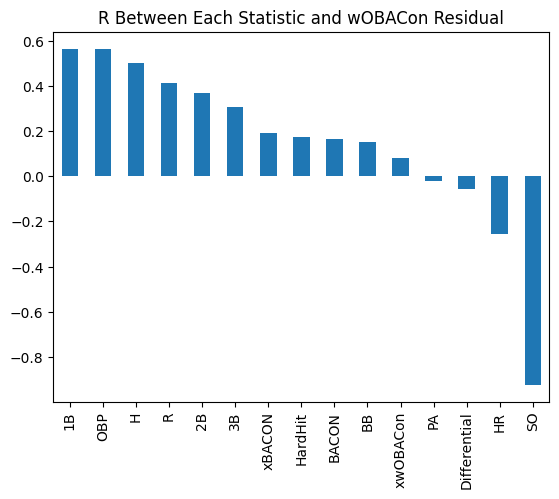

In [ ]:
cols_after = df.columns[df.columns.get_loc('Park Factor') + 1:-1].drop("wOBACon")
residuals = df[cols_after].corrwith(df['residuals']).sort_values(ascending=False)
residuals.plot.bar(title="R Between Each Statistic and wOBACon Residual")

<Axes: title={'center': 'R^2 Between Each Statistic and wOBACon Residual'}>

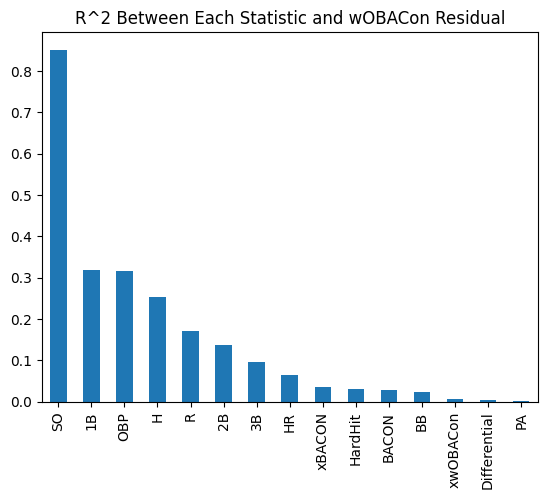

In [ ]:
r_2 = (residuals ** 2).sort_values(ascending=False)
r_2.plot.bar(title="R^2 Between Each Statistic and wOBACon Residual")

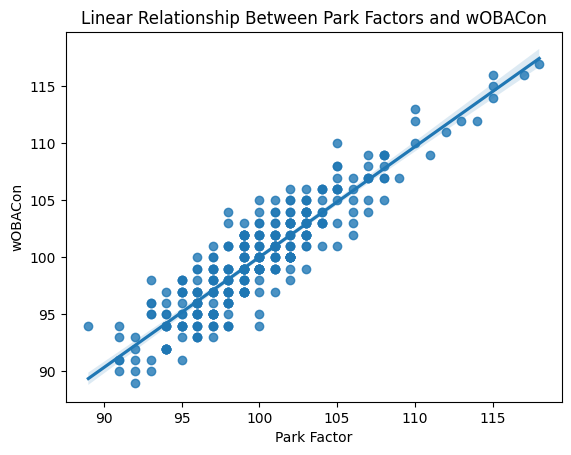

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(x='Park Factor', y='wOBACon', data=df,)
plt.title("Linear Relationship Between Park Factors and wOBACon")
plt.show()


In [ ]:
sm.OLS(df['Park Factor'],
       sm.add_constant(df[['SO']])
).fit().summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            Park Factor   R-squared:                       0.210
Model:                            OLS   Adj. R-squared:                  0.208
Method:                 Least Squares   F-statistic:                     87.24
Date:                Tue, 10 Feb 2026   Prob (F-statistic):           1.51e-18
Time:                        04:49:08   Log-Likelihood:                -933.94
No. Observations:                 330   AIC:                             1872.
Df Residuals:                     328   BIC:                             1879.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        129.5951      3.183     40.709      0.000     123.332     135.858
SO            -0.2967      0.032     -9.340      0.000      -0.359      -0.234
==============================================================================
Omnibus:                       12.159   Durbin-Watson:                   1.098
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               12.990
Skew:                           0.405   Prob(JB):                      0.00151
Kurtosis:                       3.539   Cond. No.                     1.41e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.41e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
df[['OBP', 'wOBACon']].corr()


,OBP,wOBACon
OBP,1.000000,0.774272
wOBACon,0.774272,1.000000


In [ ]:

X = sm.add_constant(df['OBP'])
y = df['Park Factor']

model = sm.OLS(y, X).fit()
df['residuals_2'] = model.resid

model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            Park Factor   R-squared:                       0.879
Model:                            OLS   Adj. R-squared:                  0.879
Method:                 Least Squares   F-statistic:                     2383.
Date:                Tue, 10 Feb 2026   Prob (F-statistic):          1.78e-152
Time:                        04:49:08   Log-Likelihood:                -624.39
No. Observations:                 330   AIC:                             1253.
Df Residuals:                     328   BIC:                             1260.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -6.6218      2.185     -3.031      0.003     -10.920      -2.324
OBP            1.0660      0.022     48.812      0.000       1.023       1.109
==============================================================================
Omnibus:                        8.199   Durbin-Watson:                   1.944
Prob(Omnibus):                  0.017   Jarque-Bera (JB):                4.647
Skew:                           0.058   Prob(JB):                       0.0979
Kurtosis:                       2.430   Cond. No.                     2.47e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.47e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

<Axes: title={'center': 'R Between Each Statistic and OBP Residual'}>

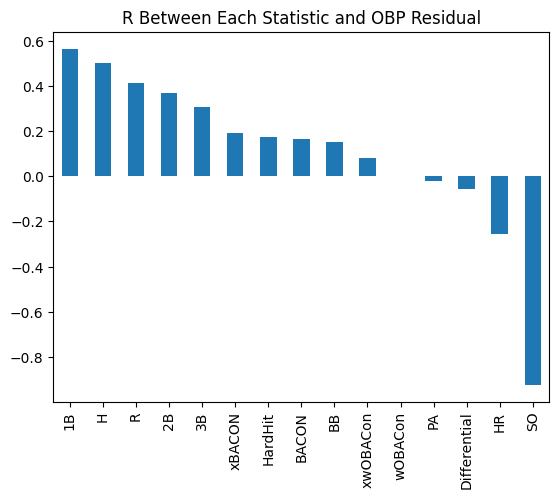

In [ ]:
cols_after = df.columns[df.columns.get_loc('Park Factor') + 1:-2].drop("OBP")
residuals = df[cols_after].corrwith(df['residuals']).sort_values(ascending=False)
residuals.plot.bar(title="R Between Each Statistic and OBP Residual")

<Axes: title={'center': 'R^2 Between Each Statistic and OBP Residual'}>

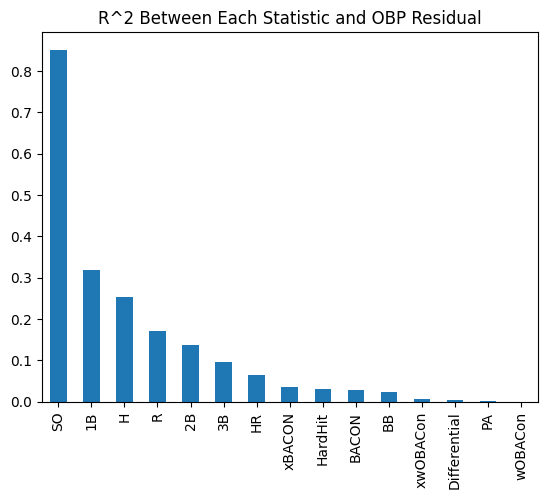

In [ ]:
r_2 = (residuals ** 2).sort_values(ascending=False)
r_2.plot.bar(title="R^2 Between Each Statistic and OBP Residual")